# Hilbert Space Sector Dimension ($\dim \mathcal{H}$) and Barren Plateau Analysis
This notebook analyzes variational quantum circuits (UCC and Trotter ansätze) for the Fermi-Hubbard model at fixed interaction strength $U = 8.0$ (u_idx=33), reusing the `"barren_study"`-labeled Trotter-scan runs (`run_trotter_scan_optimization.jl --run_label=barren_study`) and exact-exponential (full matrix-exponential) UCC runs computed across 10 system sizes at half-ish filling:
$N=(2, 2)_{3\times 2}$, $N=(3, 2)_{3\times 2}$, $N=(3, 2)_{3\times 3}$, $N=(3, 3)_{3\times 2}$, $N=(3, 3)_{3\times 3}$, $N=(3, 3)_{4\times 2}$, $N=(4, 3)_{3\times 3}$, $N=(4, 4)_{3\times 3}$, $N=(5, 4)_{3\times 3}$, $N=(5, 4)_{4\times 3}$.
Four primary analyses and figures are produced:
1. **Energy Error vs Sector Dimension ($\dim \mathcal{H}$)**: Ground-state energy error $|E_{\textrm{approx}} - E_{\textrm{true}}|$ vs Hilbert space sector dimension on a log-log scale. Compares the optimized exact-exponential UCC ansatz against the post-hoc "Trotterized exact exp" sweep (the already-optimized exact-exp coefficients, repeated $P$ times and rescaled by $1/P$, applied with NO re-optimization -- an approximation OF an approximation, so its error can only sit at or above the exact-exp error) at Trotter repetition counts $P \in \{1, 2, 3, 4, 6, 8\}$.
2. **Overlap vs Sector Dimension ($\dim \mathcal{H}$)**: Overlap (or infidelity $1 - |\langle E_0(U)|\mathcal{U}|\psi_\text{ref}\rangle|^2$) vs sector dimension. Compares the optimized exact-exponential UCC ansatz against the same post-hoc "Trotterized exact exp" sweep at depths $P \in \{1, 2, 3, 4, 6, 8\}$.
3. **Overlap and Energy vs Trotter Order for $N=(5, 4)_{4\times 3}$**: Two side-by-side panels (overlap and energy) vs Trotter order $P = 1 \dots 10$ using post-hoc repeat-and-rescale exact-exp coefficients, compared against horizontal reference lines for exact-exp and optimized Trotter ($P=1$), with a power-law infidelity fit ($1 - |\langle E_0(U)|\mathcal{U}|\psi_\text{ref}\rangle|^2 \sim c / P^{\alpha}$).
4. **Barren Plateau Initial-Gradient Statistics vs $\dim \mathcal{H}$**: Per-parameter initial-gradient magnitude $\|\nabla \mathcal{L}\| / \sqrt{n_{\textrm{params}}}$ (mean and standard deviation) vs $\dim \mathcal{H}$, comparing UCC ($P=1$) against a deeper VQE-like ansatz ($P=4$).


In [8]:
using Pkg
if !@isdefined(NOTEBOOK_DIR)
    const NOTEBOOK_DIR = @__DIR__
end
# Ensure the experimenting project environment is active
if Base.active_project() != normpath(joinpath(NOTEBOOK_DIR, "..", "Project.toml")) && isfile(joinpath(NOTEBOOK_DIR, "..", "Project.toml"))
    Pkg.activate(normpath(joinpath(NOTEBOOK_DIR, "..")))
end

include(joinpath(NOTEBOOK_DIR, "fig4_lib.jl"))
using Statistics
using LsqFit


## Configuration and Parameters
Define the target interaction strength $U = 8.0$, reference state convention, systems to analyze, and Trotter depths.


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONSTANTS & CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

const DIMH_SWEEP_SYSTEMS = [
    "N=(2, 2)_3x2", "N=(3, 2)_3x2", "N=(3, 2)_3x3", "N=(3, 3)_3x2", "N=(3, 3)_3x3",
    "N=(3, 3)_4x2", "N=(4, 3)_3x3", "N=(4, 4)_3x3", "N=(5, 4)_3x3", "N=(5, 4)_4x3",
]
const SINGLE_SYSTEM_FOR_TROTTER_ORDER_SWEEP = "N=(5, 4)_4x3"
const U_TARGET = 8.0
const REF_STATE_ARG = "slater"
const ANTIHERMITIAN = true
const LOSS_TYPE = :overlap
# Figure (c)'s barren-plateau gradient-norm data is loaded from runs optimized with
# ENERGY loss instead of overlap loss (everything else about figure (c) -- systems,
# P_vqe, normalization -- is unchanged); figures (a)/(a-alt)/(b) still use LOSS_TYPE.
const LOSS_TYPE_BARREN = :energy

# Which saved exact-exponential (UCC) coefficient set figures (a)/(a-alt)/(b) are built
# from. `nothing` selects the default, unlabelled files; a string selects the files
# written by `run_lanczos_scan_optimization.jl --run_label=<label>`. Set it to "noreg"
# to use the coefficients optimized with the L2 penalty on the loss switched off
# (--regularization=0), which is the like-for-like comparison against the Trotter
# ansatz -- the Trotter losses carry no such penalty. Deliberately NOT `const`, so a
# driver script can override it before calling compute_dimH_data.
EXACT_RUN_LABEL = nothing

# Directory to save generated PNG and PDF figures
output_dir = joinpath(NOTEBOOK_DIR, "good_images/final")
mkpath(output_dir)

# Trotter orders to plot for figures (a) and (a-alt)
trotter_orders_a = [1, 2, 3, 4, 6, 8]

# Trotter depth (num_exponentials) for the deeper VQE-like ansatz in figure (c)
P_vqe = 4

# Trotter repetition counts swept for figure (b)
trotter_orders_b = collect(1:10)

# Optional profiling toggle: prints @elapsed timings for major sub-steps
profile = false


false

## Data Loading Helpers
Helper functions to resolve system directories inside `get_data_root()` and retrieve multi-start optimization metrics from `barren_study` JLD2 files.


In [3]:
"""
    resolve_system_folder(input::String) -> String

Resolves a system-folder name to a full directory path inside get_data_root().
Duplicated (verbatim) from trotter_exp_testing.jl's own copy, since that file is a
script entry point and cannot be `include`d here.
"""
function resolve_system_folder(input::String)
    if isabspath(input) && isdir(input)
        return input
    end
    root = get_data_root()
    p1 = joinpath(root, input)
    if isdir(p1)
        return p1
    end
    for item in readdir(root)
        if isdir(joinpath(root, item))
            if item == input || endswith(item, "_" * input)
                return joinpath(root, item)
            end
        end
    end
    error("Could not resolve system size / folder: '$input' in data root '$root'")
end

"""
    load_barren_study_trotter_metrics(folder, N_sites, P; ...) -> (energy, overlap, gnorms) or nothing

Loads the directly-optimized Trotter ansatz "barren_study" run for the given system
folder, site count `N_sites`, and Trotter depth (num_exponentials) `P`, all at U-index
33 (U=8.0). Returns `nothing` if the file does not exist. `gnorms` is the vector of
initial-gradient norms sampled during multi-start initialization (one per random init).
"""
function load_barren_study_trotter_metrics(
    folder::String, N_sites::Int, P::Int;
    custom_ref_state_arg::Union{String,Nothing}=REF_STATE_ARG,
    antihermitian::Bool=ANTIHERMITIAN,
    loss_type::Symbol=LOSS_TYPE,
    u_idx::Int=33,
)
    prefix = build_save_name_prefix(
        :trotter; sites=N_sites, custom_ref_state_arg=custom_ref_state_arg,
        antihermitian=antihermitian, loss_type=loss_type, num_exponentials=P,
        suffix="barren_study",
    )
    fpath = joinpath(folder, "$(prefix)_u_$(u_idx).jld2")
    if !isfile(fpath)
        @warn "Missing barren_study Trotter file (num_exponentials=$P): $fpath"
        return nothing
    end
    d = load(fpath)["dict"]
    met = d["metrics"]
    energy = (haskey(met, "energy") && !isempty(met["energy"])) ? met["energy"][end] : NaN
    overlap = (haskey(met, "loss") && !isempty(met["loss"])) ? 1.0 - met["loss"][end] : NaN
    gnorms = Float64[]
    if haskey(met, "initial_gradient_samples") && !isempty(met["initial_gradient_samples"])
        samples = met["initial_gradient_samples"][1]
        gnorms = [s[2] for s in samples]
    end
    return (energy=energy, overlap=overlap, gnorms=gnorms)
end


load_barren_study_trotter_metrics

## System Computation Routines
Functions to compute Hilbert space dimensions, ground-state energy, exact-exponential metrics, directly-optimized Trotter energies and overlaps, and per-parameter normalized gradient samples.


In [4]:
"""
    compute_one_system_data(name; trotter_orders_a, P_vqe, compute_order_sweep, trotter_orders_b, profile)
        -> (NamedTuple, Union{Nothing,Tuple})

Computes one system's dimH-sweep data point: the Hilbert-space sector dimension
(dimH), the true ground-state energy at U=8.0, the full matrix-exponential (exact-exp)
energy and overlap, a Dict{Int,Float64} of the post-hoc "Trotterized exact exp" energy
and overlap (trotterized_exact_exp_energies/_overlaps: the already-optimized exact-exp
coefficients, repeated P times and rescaled by 1/P, applied with NO re-optimization) at
each P in `trotter_orders_a` (feeding plots (a) and (a-alt)), and the PER-PARAMETER
initial-gradient-magnitude samples (raw gradient norm / sqrt(n_params)) for both the UCC
(num_exponentials=1) and VQE-like (num_exponentials=P_vqe) ansätze (feeding plot (c)).

Also still computes (but does NOT feed plots (a)/(a-alt) with) trotter_before_energies/
trotter_before_overlaps: the DIRECTLY re-optimized Trotter ansatz's own energy/overlap at
each num_exponentials=P (P independently-optimized copies of the gate coefficients, NOT
a post-hoc repeat/rescale) -- kept as reference data since it's a different variational
manifold with no ordering guarantee against exact-exp (unlike trotterized_exact_exp_*,
which can only ever be as good as or worse than exact-exp).

If `compute_order_sweep` is true, this system's setup_system/get_exact_coefficients
results are ALSO reused in the same call to compute the data needed for plot (b) (the
"Exact exponential" and "Optimized trotter" [num_exponentials=1] reference values, and
the "Trotterized exact exp" sweep over `trotter_orders_b`), avoiding a second, separate
setup_system/get_exact_coefficients call on that folder. In that case the second return
value is a `(exact_energy, exact_overlap, optimized_trotter_energy,
optimized_trotter_overlap, trotter_orders_b, energies_after, overlaps_after)` tuple;
otherwise it is `nothing`.

If `profile` is true, prints `@elapsed` timings (wall-clock seconds) for each major
sub-step to stdout, prefixed with the system name, so the dominant cost can be
identified per system size.
"""
function compute_one_system_data(
    name::String;
    trotter_orders_a::Vector{Int}=[1, 2, 3, 4, 6, 8], P_vqe::Int=4,
    compute_order_sweep::Bool=false,
    trotter_orders_b::Vector{Int}=collect(1:10),
    profile::Bool=false,
)
    folder = resolve_system_folder(name)
    println("\n=== System: $name ===")

    t_setup = @elapsed begin
        U_values, target_vecs, indexer, sign_convention, antihermitian, H_hop_mom, H_int_mom,
        basis_ints, gates, num_gates, N_sites, n_up_loaded, n_dn_loaded =
            setup_system(folder, REF_STATE_ARG, ANTIHERMITIAN, LOSS_TYPE)
    end

    dimH = length(basis_ints)
    n_U = length(U_values)
    u_i = findmin(abs.(U_values .- U_TARGET))[2]
    U_actual = U_values[u_i]

    has_prepended_ref = (size(target_vecs, 1) == n_U + 1)
    gs_state = ComplexF64.(vec(target_vecs[has_prepended_ref ? u_i + 1 : u_i, :]))
    H_u = H_hop_mom + U_actual * H_int_mom
    gs_energy = compute_energy(gs_state, H_u)
    ref_state = ComplexF64.(vec(target_vecs[1, :]))

    # Exact-exp (full matrix exponential) coefficients + energy/overlap
    t_exact_coeffs = @elapsed begin
        exact_coeffs_raw, t_keys, exact_coeffs = get_exact_coefficients(
            folder, U_values, n_up_loaded, n_dn_loaded, REF_STATE_ARG, antihermitian,
            LOSS_TYPE, sign_convention, gates, indexer, basis_ints;
            run_label=EXACT_RUN_LABEL,
        )
    end
    exact_exp_energy = NaN
    exact_exp_overlap = NaN
    t_exact_exp = @elapsed if !isnothing(t_keys) && !isnothing(exact_coeffs_raw[u_i])
        e_vals, o_vals, _ = compute_exact_exp_energies_and_overlaps(
            [exact_coeffs_raw[u_i]], t_keys, indexer, collect(Int, indexer.lattice_dims),
            basis_ints, ref_state, [gs_state], H_hop_mom, H_int_mom, [U_actual];
            antihermitian=antihermitian, sign_convention=sign_convention,
        )
        exact_exp_energy, exact_exp_overlap = e_vals[1], o_vals[1]
    else
        @warn "No exact-exp coefficients for $name; skipping."
    end

    # Directly-optimized Trotter ansatz at each num_exponentials=P in trotter_orders_a, for plots (a) and (a-alt)
    trotter_a_metrics = Dict{Int,Any}()
    t_load_barren = @elapsed for P in trotter_orders_a
        trotter_a_metrics[P] = load_barren_study_trotter_metrics(folder, N_sites, P)
    end
    trotter_before_energies = Dict{Int,Float64}(
        P => (isnothing(m) ? NaN : m.energy) for (P, m) in trotter_a_metrics
    )
    trotter_before_overlaps = Dict{Int,Float64}(
        P => (isnothing(m) ? NaN : m.overlap) for (P, m) in trotter_a_metrics
    )

    # "Trotterized exact exp" sweep at each post-hoc Trotter repetition count P in
    # trotter_orders_a -- feeds plots (a)/(a-alt). Post-hoc repeat-and-rescale of the
    # already-optimized exact_coeffs[u_i], NO re-optimization (same calculation as the
    # trotter_orders_b sweep further down / plot (b)'s "Trotterized exact exp" line).
    trotterized_exact_exp_energies = Dict{Int,Float64}(P => NaN for P in trotter_orders_a)
    trotterized_exact_exp_overlaps = Dict{Int,Float64}(P => NaN for P in trotter_orders_a)
    t_trotterize_a = @elapsed if !isnothing(exact_coeffs[u_i])
        energies_dict_a, overlaps_dict_a, _ = compute_trotterized_energies_and_overlaps(
            [exact_coeffs[u_i]], trotter_orders_a, gates, ref_state, basis_ints, [gs_state],
            N_sites, H_hop_mom, H_int_mom, [U_actual], num_gates; antihermitian=antihermitian,
        )
        for P in trotter_orders_a
            trotterized_exact_exp_energies[P] = energies_dict_a[P][1]
            trotterized_exact_exp_overlaps[P] = overlaps_dict_a[P][1]
        end
    else
        @warn "No exact-exp coefficients for $name; 'Trotterized exact exp' series (plot a) will be all-NaN."
    end

    # UCC (num_exponentials=1) and VQE-like (num_exponentials=P_vqe) gradient samples for plot (c),
    # normalized to a per-parameter magnitude (gnorm / sqrt(n_params)) -- these are loaded with
    # LOSS_TYPE_BARREN (energy/Hamiltonian loss), independent of the LOSS_TYPE (overlap loss) runs
    # used for trotter_a_metrics/plots (a)/(a-alt) above. Fixed from a previous version of this cell
    # that reused trotter_a_metrics (overlap-loss) here instead -- that mixed overlap-optimized
    # gradient statistics into what figure (c) documents as an energy-loss barren-plateau comparison.
    ucc_metrics = load_barren_study_trotter_metrics(folder, N_sites, 1; loss_type=LOSS_TYPE_BARREN)
    ucc_n_params = num_gates
    ucc_gnorms = isnothing(ucc_metrics) ? Float64[] : ucc_metrics.gnorms ./ sqrt(ucc_n_params)

    vqe_metrics = load_barren_study_trotter_metrics(folder, N_sites, P_vqe; loss_type=LOSS_TYPE_BARREN)
    vqe_n_params = P_vqe * num_gates
    vqe_gnorms = isnothing(vqe_metrics) ? Float64[] : vqe_metrics.gnorms ./ sqrt(vqe_n_params)

    # Directly-optimized Trotter energy and overlap from the standard trotter_...jld2 files
    opt_trotter_energy = NaN
    opt_trotter_overlap = NaN
    e_opt, o_opt = load_trotter_opt_energies_and_overlaps(
        folder, N_sites, [U_actual];
        custom_ref_state_arg=REF_STATE_ARG, antihermitian=ANTIHERMITIAN, loss_type=LOSS_TYPE,
        gs_energies=[gs_energy],
    )
    if !isempty(e_opt) && isfinite(e_opt[1])
        opt_trotter_energy = e_opt[1]
    end
    if !isempty(o_opt) && isfinite(o_opt[1])
        opt_trotter_overlap = o_opt[1]
    end
    if isnan(opt_trotter_energy) || isnan(opt_trotter_overlap)
        m_p1 = get(trotter_a_metrics, 1, nothing)
        isnothing(m_p1) && (m_p1 = load_barren_study_trotter_metrics(folder, N_sites, 1))
        if !isnothing(m_p1)
            isnan(opt_trotter_energy) && (opt_trotter_energy = m_p1.energy)
            isnan(opt_trotter_overlap) && (opt_trotter_overlap = m_p1.overlap)
        end
    end

    result = (
        name=name, dimH=dimH, gs_energy=gs_energy,
        exact_exp_energy=exact_exp_energy,
        exact_exp_overlap=exact_exp_overlap,
        opt_trotter_energy=opt_trotter_energy,
        opt_trotter_overlap=opt_trotter_overlap,
        trotter_before_energies=trotter_before_energies,
        trotter_before_overlaps=trotter_before_overlaps,
        trotterized_exact_exp_energies=trotterized_exact_exp_energies,
        trotterized_exact_exp_overlaps=trotterized_exact_exp_overlaps,
        ucc_gnorms=ucc_gnorms, vqe_gnorms=vqe_gnorms,
    )

    order_sweep_result = nothing
    t_order_sweep = 0.0
    if compute_order_sweep
        t_order_sweep = @elapsed begin
            gs_states = [gs_state]

            # "Trotterized exact exp, order P" sweep: post-hoc repeat-and-rescale of exact-exp coefficients
            energies_after = fill(NaN, length(trotter_orders_b))
            overlaps_after = fill(NaN, length(trotter_orders_b))
            if !isnothing(exact_coeffs[u_i])
                energies_dict, overlaps_dict, _ = compute_trotterized_energies_and_overlaps(
                    [exact_coeffs[u_i]], trotter_orders_b, gates, ref_state, basis_ints, gs_states,
                    N_sites, H_hop_mom, H_int_mom, [U_actual], num_gates; antihermitian=antihermitian,
                )
                for (idx, P) in enumerate(trotter_orders_b)
                    energies_after[idx] = energies_dict[P][1]
                    overlaps_after[idx] = overlaps_dict[P][1]
                end
            else
                @warn "No exact-exp coefficients for $name; 'Trotterized exact exp' series will be all-NaN."
            end

            order_sweep_result = (
                exact_exp_energy, exact_exp_overlap, opt_trotter_energy, opt_trotter_overlap,
                trotter_orders_b, energies_after, overlaps_after,
            )
        end
    end

    if profile
        println("  [profile] $name (dimH=$dimH): setup_system=$(round(t_setup, digits=2))s, " *
                 "get_exact_coefficients=$(round(t_exact_coeffs, digits=2))s, " *
                 "compute_exact_exp_energies_and_overlaps=$(round(t_exact_exp, digits=2))s, " *
                 "load_barren_study_trotter_metrics(x$(length(trotter_orders_a)))=$(round(t_load_barren, digits=2))s, " *
                 "trotterize_a(x$(length(trotter_orders_a)))=$(round(t_trotterize_a, digits=2))s, " *
                 "order_sweep=$(round(t_order_sweep, digits=2))s")
    end

    return result, order_sweep_result
end

"""
    compute_dimH_sweep_data(system_folders; trotter_orders_a, P_vqe,
                             order_sweep_system, trotter_orders_b, profile)
        -> (Vector{NamedTuple}, Union{Nothing,Tuple})

Computes, for each system in `system_folders`, the data needed for plots (a), (a-alt), and (c) via
`compute_one_system_data`. If `order_sweesweep_datap_system` matches one of the `system_folders`
names, that system's call also computes the data needed for plot (b) in the same pass.
"""
function compute_dimH_data(
    system_folders::Vector{String};
    trotter_orders_a::Vector{Int}=[1, 2, 3, 4, 6, 8], P_vqe::Int=4,
    order_sweep_system::Union{Nothing,String}=nothing,
    trotter_orders_b::Vector{Int}=collect(1:10),
    profile::Bool=false,
)
    raw = [
        compute_one_system_data(
            name; trotter_orders_a=trotter_orders_a, P_vqe=P_vqe,
            compute_order_sweep=(!isnothing(order_sweep_system) && name == order_sweep_system),
            trotter_orders_b=trotter_orders_b, profile=profile,
        )
        for name in system_folders
    ]

    results = [r[1] for r in raw]
    order_sweep_result = nothing
    for r in raw
        !isnothing(r[2]) && (order_sweep_result = r[2])
    end

    return results, order_sweep_result
end

"""
    compute_trotter_order_sweep_single_system(folder_name; trotter_orders_b)

Fallback path for when `folder_name` is NOT already part of the dimH-sweep system list.
"""
function compute_trotter_order_sweep_single_system(
    folder_name::String; trotter_orders_b::Vector{Int}=collect(1:10),
)
    folder = resolve_system_folder(folder_name)
    U_values, target_vecs, indexer, sign_convention, antihermitian, H_hop_mom, H_int_mom,
    basis_ints, gates, num_gates, N_sites, n_up_loaded, n_dn_loaded =
        setup_system(folder, REF_STATE_ARG, ANTIHERMITIAN, LOSS_TYPE)

    n_U = length(U_values)
    u_i = findmin(abs.(U_values .- U_TARGET))[2]
    U_actual = U_values[u_i]
    ref_state = ComplexF64.(vec(target_vecs[1, :]))
    has_prepended_ref = (size(target_vecs, 1) == n_U + 1)
    gs_state = ComplexF64.(vec(target_vecs[has_prepended_ref ? u_i + 1 : u_i, :]))
    gs_states = [gs_state]

    exact_coeffs_raw, t_keys, exact_coeffs = get_exact_coefficients(
        folder, U_values, n_up_loaded, n_dn_loaded, REF_STATE_ARG, antihermitian,
        LOSS_TYPE, sign_convention, gates, indexer, basis_ints;
        run_label=EXACT_RUN_LABEL,
    )

    exact_exp_energy = NaN
    exact_exp_overlap = NaN
    if !isnothing(t_keys) && !isnothing(exact_coeffs_raw[u_i])
        e_vals, o_vals, _ = compute_exact_exp_energies_and_overlaps(
            [exact_coeffs_raw[u_i]], t_keys, indexer, collect(Int, indexer.lattice_dims),
            basis_ints, ref_state, gs_states, H_hop_mom, H_int_mom, [U_actual];
            antihermitian=antihermitian, sign_convention=sign_convention,
        )
        exact_exp_energy, exact_exp_overlap = e_vals[1], o_vals[1]
    else
        @warn "No exact-exp coefficients for $folder_name; 'Exact exponential' line will be NaN."
    end

    opt_trotter_energy = NaN
    opt_trotter_overlap = NaN
    e_opt, o_opt = load_trotter_opt_energies_and_overlaps(
        folder, N_sites, [U_actual];
        custom_ref_state_arg=REF_STATE_ARG, antihermitian=ANTIHERMITIAN, loss_type=LOSS_TYPE,
        gs_energies=[gs_energy],
    )
    if !isempty(e_opt) && isfinite(e_opt[1])
        opt_trotter_energy = e_opt[1]
    end
    if !isempty(o_opt) && isfinite(o_opt[1])
        opt_trotter_overlap = o_opt[1]
    end
    if isnan(opt_trotter_energy) || isnan(opt_trotter_overlap)
        opt_trotter_metrics = load_barren_study_trotter_metrics(folder, N_sites, 1)
        if !isnothing(opt_trotter_metrics)
            isnan(opt_trotter_energy) && (opt_trotter_energy = opt_trotter_metrics.energy)
            isnan(opt_trotter_overlap) && (opt_trotter_overlap = opt_trotter_metrics.overlap)
        end
    end

    energies_after = fill(NaN, length(trotter_orders_b))
    overlaps_after = fill(NaN, length(trotter_orders_b))
    if !isnothing(exact_coeffs[u_i])
        energies_dict, overlaps_dict, _ = compute_trotterized_energies_and_overlaps(
            [exact_coeffs[u_i]], trotter_orders_b, gates, ref_state, basis_ints, gs_states,
            N_sites, H_hop_mom, H_int_mom, [U_actual], num_gates; antihermitian=antihermitian,
        )
        for (idx, P) in enumerate(trotter_orders_b)
            energies_after[idx] = energies_dict[P][1]
            overlaps_after[idx] = overlaps_dict[P][1]
        end
    else
        @warn "No exact-exp coefficients for $folder_name; 'Trotterized exact exp' series will be all-NaN."
    end

    return exact_exp_energy, exact_exp_overlap, opt_trotter_energy, opt_trotter_overlap,
    trotter_orders_b, energies_after, overlaps_after
end

"""
    populate_opt_trotter(data; u_target=U_TARGET) -> Vector{NamedTuple}

Quick helper to attach opt_trotter_energy and opt_trotter_overlap to an existing
`data` vector in memory in < 1 second, avoiding re-running compute_dimH_data.
"""
function populate_opt_trotter(data; u_target=U_TARGET)
    new_data = []
    for d in data
        folder = resolve_system_folder(d.name)
        m = match(r"_(\d+)x(\d+)", d.name)
        N_sites = parse(Int, m[1]) * parse(Int, m[2])
        e_opt, o_opt = load_trotter_opt_energies_and_overlaps(
            folder, N_sites, [u_target];
            custom_ref_state_arg=REF_STATE_ARG, antihermitian=ANTIHERMITIAN, loss_type=LOSS_TYPE,
            gs_energies=[d.gs_energy],
        )
        opt_energy = !isempty(e_opt) ? e_opt[1] : NaN
        opt_overlap = !isempty(o_opt) ? o_opt[1] : NaN
        push!(new_data, merge(d, (opt_trotter_energy=opt_energy, opt_trotter_overlap=opt_overlap)))
    end
    return [d for d in new_data]
end


populate_opt_trotter

## CairoMakie Plotting Functions
Functions constructing publication-quality figures matching the styling of `plot_dimH_and_barren_analysis.jl`.


In [5]:
"""
    build_energy_error_vs_dimH_plot(data, trotter_orders_a) -> Figure

Plot (a): |E_approx - E_true| vs Hilbert-space sector dimension dimH. One black line
"Optimized exact exp" for the full matrix-exponential (exact-exp) UCC ansatz, a red
"Optimized trotter" reference line (opt_trotter_energy, num_exponentials=1), plus one
"Trotterized exact exp, P=<P>" line per post-hoc Trotter repetition count P in
`trotter_orders_a`: the ALREADY-optimized exact-exp coefficients, repeated P times and
rescaled by 1/P and applied with NO re-optimization -- its error can only sit at or
above "Optimized exact exp"'s error, converging down to it as P grows.
"""
function build_energy_error_vs_dimH_plot(data::Vector{<:NamedTuple}, trotter_orders_a::Vector{Int})
    dims = Float64[d.dimH for d in data]
    order = sortperm(dims)
    dims_s = dims[order]

    fig, ax = create_fig(1, 55.0;
        xlabel=L"\dim \mathcal{H}",
        ylabel=L"|E_{\textrm{approx}} - E_{\textrm{true}}|",
        xscale=log10, yscale=log10,
    )

    palette = cmap2(length(trotter_orders_a))
    for (idx, P) in enumerate(trotter_orders_a)
        errs = [abs(get(d.trotterized_exact_exp_energies, P, NaN) - d.gs_energy) for d in data][order]
        valid_p = isfinite.(errs) .& (errs .> 0)
        if any(valid_p)
            scatterlines!(ax, dims_s[valid_p][2:end], errs[valid_p][2:end];
                label=L"\textrm{Trotter after optimize}\;(m=%$P)", color=palette[idx], linewidth=1.5, markersize=6,linestyle=:dash
            )
        end
    end

    err_exact = [abs(d.exact_exp_energy - d.gs_energy) for d in data][order]
    err_trotter = [abs(d.opt_trotter_energy - d.gs_energy) for d in data][order]
    scatterlines!(ax, dims_s[2:end], err_exact[2:end]; label=L"\textrm{Exact exp}\;(m=\infty)", color=:black, linewidth=1.5, markersize=6, linestyle=:dash)
    scatterlines!(ax, dims_s[2:end], err_trotter[2:end]; label=L"\textrm{Optimized trotter}", color=:red, linewidth=1.8, markersize=6)


    axislegend(ax; position=:rb, backgroundcolor=(:white, 0.8), LEGEND_ARGS...)
    return fig
end

"""
    build_overlap_vs_dimH_plot(data, trotter_orders_a; use_infidelity=false, legend_pos=:lb) -> Figure

Plot (a-alt): Overlap (or infidelity 1 - overlap if `use_infidelity=true`) vs Hilbert-space
sector dimension dimH. One black line "Optimized exact exp" for the full matrix-exponential
(exact-exp) UCC ansatz, plus one "Trotterized exact exp, P=<P>" line per post-hoc Trotter
repetition count P in `trotter_orders_a` (see build_energy_error_vs_dimH_plot's docstring).
"""
function build_overlap_vs_dimH_plot(
    data::Vector{<:NamedTuple}, trotter_orders_a::Vector{Int};
    use_infidelity::Bool=false,
    legend_pos::Symbol=:lb,
)
    dims = Float64[d.dimH for d in data]
    order = sortperm(dims)
    dims_s = dims[order]

    ylabel_str = use_infidelity ? L"1 - |\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2" : L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2"
    yscale_val = use_infidelity ? log10 : identity

    fig, ax = create_fig(1, 55.0;
        xlabel=L"\dim \mathcal{H}",
        ylabel=ylabel_str,
        xscale=log10, yscale=yscale_val,
    )


    palette = cmap2(length(trotter_orders_a))
    for (idx, P) in enumerate(trotter_orders_a)
        overlaps_p = [
            hasproperty(d, :trotterized_exact_exp_overlaps) ? get(d.trotterized_exact_exp_overlaps, P, NaN) : NaN
            for d in data
        ][order]

        vals_p = use_infidelity ? (1.0 .- overlaps_p) : overlaps_p
        valid_p = isfinite.(vals_p) .& (use_infidelity ? (vals_p .> 0) : true)
        if any(valid_p)
            scatterlines!(ax, dims_s[valid_p], vals_p[valid_p];
                label=L"\textrm{Opt exact exp}\;m=%$P", color=palette[idx], linewidth=1.5, markersize=6,
            )
        end
    end
    one_minus(x, cond) = cond ? (1.0 .- x) : x
    ov_exact = [d.exact_exp_overlap for d in data][order]
    ov_trotter = [d.opt_trotter_overlap for d in data][order]

    scatterlines!(ax, dims_s, one_minus(ov_exact, use_infidelity);
        label=L"\textrm{Opt exact exp}\; m=\infty", color=:black, linewidth=1.5, markersize=6,
    )
    scatterlines!(ax, dims_s, one_minus(ov_trotter, use_infidelity);
        label=L"\textrm{Opt trotter}\;m=1", color=:red, linewidth=1.5, markersize=6,
    )


    axislegend(ax; position=legend_pos, backgroundcolor=(:white, 0.8), LEGEND_ARGS...)
    return fig
end

"""
    build_overlap_energy_vs_trotter_order_plot(exact_energy, exact_overlap,
        opt_trotter_energy, opt_trotter_overlap, orders_b, energies_after, overlaps_after) -> Figure

Plot (b): for the single target system (num_exponentials fixed at 1 throughout), two
side-by-side linear-x-axis panels (left = overlap, right = energy) vs Trotter order P,
each with three lines: a constant "Exact exponential" reference line, a constant
"Optimized trotter" (num_exponentials=1) reference line, and the "Trotterized exact
exp, order P" sweep (post-hoc repeat-and-rescale of the exact-exp coefficients,
swept over `orders_b`) with a power-law fit extrapolated to P=10.
"""
function build_overlap_energy_vs_trotter_order_plot(
    exact_energy::Float64, exact_overlap::Float64,
    opt_trotter_energy::Float64, opt_trotter_overlap::Float64,
    orders_b::Vector{Int}, energies_after::Vector{Float64}, overlaps_after::Vector{Float64},
)
    fig = Figure(size=get_figsize(2, 65.0), figure_padding=5)
    ax_overlap = Axis(fig[1, 1];
        xlabel=L"\textrm{Trotter order } m", ylabel=L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
        aspect=(1 + sqrt(5)) / 2,
    )
    ax_energy = Axis(fig[1, 2];
        xlabel=L"\textrm{Trotter order } m", ylabel=L"\langle H\rangle",
        aspect=(1 + sqrt(5)) / 2,
    )

    color_exact = :black
    color_opt = :crimson
    color_after = :dodgerblue

    P_lo, P_hi = Float64(minimum(orders_b)), 10.0
    valid_a = isfinite.(overlaps_after)

    if isfinite(exact_overlap)
        hlines!(ax_overlap, [exact_overlap]; color=color_exact, linewidth=2, label=L"\textrm{Exact exponential}")
    end
    if isfinite(opt_trotter_overlap)
        hlines!(ax_overlap, [opt_trotter_overlap]; color=color_opt, linewidth=2, label=L"\textrm{Optimized trotter}")
    end
    if any(valid_a)
        scatterlines!(ax_overlap, Float64.(orders_b[valid_a]), overlaps_after[valid_a]; color=color_after, linewidth=2, markersize=6, label=L"\textrm{Trotterized exact exp}")
    end

    if isfinite(exact_energy)
        hlines!(ax_energy, [exact_energy]; color=color_exact, linewidth=2, label=L"\textrm{Exact exponential}")
    end
    if isfinite(opt_trotter_energy)
        hlines!(ax_energy, [opt_trotter_energy]; color=color_opt, linewidth=2, label=L"\textrm{Optimized trotter}")
    end
    valid_ae = isfinite.(energies_after)
    if any(valid_ae)
        scatterlines!(ax_energy, Float64.(orders_b[valid_ae]), energies_after[valid_ae]; color=color_after, linewidth=2, markersize=6, label=L"\textrm{Trotterized exact exp}")
    end

    # Power-law fit/extrapolation of the "Trotterized exact exp" infidelity vs P, capped at P=10
    if count(valid_a) >= 2
        # overlap fit
        infid_after = 1.0 .- overlaps_after[valid_a]
        weighting_func(z) = log10.(abs.(z .- infid_after[end] .+ 1e-4))
        exp_fit(x, p) = p[1] .+ abs(p[2]) .* exp.(-p[3].*x)
        x = collect(range(P_lo, P_hi; length=100))
        fit = curve_fit((x,p)->weighting_func(exp_fit(x,p)), Float64.(orders_b[valid_a]), weighting_func(infid_after), [1e-4, 0.4, 0.6192467214869578])
        lines!(ax_overlap, x, 1 .- exp_fit(x, fit.param);
            color=color_after, linewidth=1.2, linestyle=:dot,
            label="Exponential fit",
        )

        # energy fit
        energies_after = energies_after[valid_ae]
        weighting_func(z) = log10.(abs.(z .- energies_after[end] .+ 1e-4))
        fit = curve_fit((x,p)->weighting_func(exp_fit(x,p)), Float64.(orders_b[valid_ae]), weighting_func(energies_after), [-10, 0.4, 0.6192467214869578])
        lines!(ax_energy, x, exp_fit(x, fit.param);
            color=color_after, linewidth=1.2, linestyle=:dot,
            label="Exponential fit",
        )

    end

    xlims!(ax_overlap, P_lo, P_hi)
    xlims!(ax_energy, P_lo, P_hi)

    axislegend(ax_overlap; position=:rb, backgroundcolor=(:white, 0.8), LEGEND_ARGS...)
    axislegend(ax_energy; position=:rt, backgroundcolor=(:white, 0.8), LEGEND_ARGS...)
    return fig
end

"""
    build_barren_plateau_vs_dimH_plot(data, P_vqe) -> Figure

Plot (c): per-parameter initial-gradient-magnitude statistics (gnorm / sqrt(n_params))
vs Hilbert-space sector dimension dimH, comparing UCC (num_exponentials=1) against a
VQE-like deeper ansatz (num_exponentials=P_vqe). Two side-by-side panels: (c1)
mean vs dimH; (c2) std vs dimH (a simple proxy for barren-plateau "width").
"""
function build_barren_plateau_vs_dimH_plot(data::Vector{<:NamedTuple}, P_vqe::Int)
    dims = Float64[d.dimH for d in data]
    order = sortperm(dims)
    dims_s = dims[order]

    ucc_mean = [isempty(d.ucc_gnorms) ? NaN : mean(d.ucc_gnorms) for d in data][order]
    ucc_std = [length(d.ucc_gnorms) < 2 ? NaN : std(d.ucc_gnorms) for d in data][order]
    vqe_mean = [isempty(d.vqe_gnorms) ? NaN : mean(d.vqe_gnorms) for d in data][order]
    vqe_std = [length(d.vqe_gnorms) < 2 ? NaN : std(d.vqe_gnorms) for d in data][order]

    fig = Figure(size=get_figsize(2, 60.0), figure_padding=5)
    ax1 = Axis(fig[1, 1]; xlabel=L"\dim \mathcal{H}", ylabel=L"\textrm{mean } \|\nabla \mathcal{L}\| / \sqrt{n_{\textrm{params}}}", xscale=log10, yscale=log10, aspect=(1 + sqrt(5)) / 2)
    ax2 = Axis(fig[1, 2]; xlabel=L"\dim \mathcal{H}", ylabel=L"\textrm{std } \|\nabla \mathcal{L}\| / \sqrt{n_{\textrm{params}}}", xscale=log10, yscale=log10, aspect=(1 + sqrt(5)) / 2)

    for (means, stds, label, color) in (
        (ucc_mean, ucc_std, L"\textrm{UCC } (L=1)", :black),
        (vqe_mean, vqe_std, L"\textrm{VQE-like } (L=%$P_vqe)", :crimson),
    )
        valid_m = isfinite.(means) .& (means .> 0)
        if any(valid_m)
            scatterlines!(ax1, dims_s[valid_m], means[valid_m]; label=label, color=color, linewidth=1.5, markersize=6)
        end
        valid_s = isfinite.(stds) .& (stds .> 0)
        if any(valid_s)
            scatterlines!(ax2, dims_s[valid_s], stds[valid_s]; label=label, color=color, linewidth=1.5, markersize=6)
        end
    end

    axislegend(ax1; position=:lb, backgroundcolor=(:white, 0.8), LEGEND_ARGS...)
    axislegend(ax2; position=:lb, backgroundcolor=(:white, 0.8), LEGEND_ARGS...)
    return fig
end


build_barren_plateau_vs_dimH_plot

## Execute Data Collection
Computes metrics across all 10 system sizes at $U = 8.0$.
Notice that $N=(5, 4)_{4\times 3}$ performs its Trotter-order sweep within the same pass to avoid duplicate setup overhead.


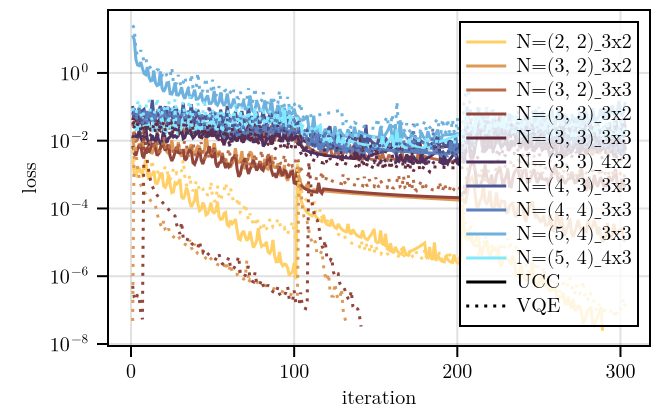

CairoMakie.Screen{IMAGE}


In [9]:
include("data_path.jl")
fig, ax = create_fig(1, 55.0; 
yscale=log10, 
ylabel="loss", xlabel="iteration")
global f
palette = cmap2(length(DIMH_SWEEP_SYSTEMS))
for (num_exp, label, linestyle) in [(1, "UCC", :solid),  (4, "VQE", :dot)]
    for (i, folder) in enumerate(DIMH_SWEEP_SYSTEMS)
        # load_barren_study_trotter_metrics(
        # folder::String, N_sites::Int, P::Int;
        # custom_ref_state_arg::Union{String,Nothing}=REF_STATE_ARG,
        # antihermitian::Bool=ANTIHERMITIAN,
        # loss_type::Symbol=LOSS_TYPE,
        # u_idx::Int=33,
        U_values, target_vecs, indexer, sign_convention, antihermitian, H_hop_mom, H_int_mom, basis_ints, gates, num_gates, N_sites, n_up_loaded, n_dn_loaded = setup_system(data_folder(folder), "slater", true,:energy; verbose=false)
        H_dim = size(target_vecs, 2)

        # global d = load_barren_study_trotter_metrics(folder, N_sites, 1; custom_ref_state_arg="slater", antihermitian=true, loss_type=:energy)
        prefix = build_save_name_prefix(
            :trotter; sites=N_sites, custom_ref_state_arg="slater",
            antihermitian=true, loss_type=:energy, num_exponentials=num_exp,
            suffix="barren_study",
        )
        fpath = joinpath(folder, "$(prefix)_u_$(33).jld2")
        d = load(data_folder(fpath))["dict"]
        met = d["metrics"]

        lines!(ax, norm.(met["optimization_gradients"][1]), label=label == "UCC" ? folder : nothing, color=palette[i], linestyle=linestyle)
        # lines!(ax, met["optimization_losses"][1] .- met["optimization_losses"][1][end] .+ 1e-14, label=folder)
    end
end
lines!(ax, [NaN], [NaN];
    color = :black, linestyle = :solid,
    label = "UCC")
lines!(ax, [NaN], [NaN];
    color = :black,linestyle = :dot,
    label = "VQE")
axislegend(ax; LEGEND_ARGS..., backgroundcolor=(:white, 0.8))
save("tmp.png", fig)
display(fig)

In [10]:
println("### Computing dimH-sweep data across $(length(DIMH_SWEEP_SYSTEMS)) systems ###")
sweep_data, order_sweep_result = compute_dimH_data(
    DIMH_SWEEP_SYSTEMS;
    trotter_orders_a=trotter_orders_a,
    P_vqe=P_vqe,
    order_sweep_system=SINGLE_SYSTEM_FOR_TROTTER_ORDER_SWEEP,
    trotter_orders_b=trotter_orders_b,
    profile=profile,
)

if isnothing(order_sweep_result)
    println("\n### $SINGLE_SYSTEM_FOR_TROTTER_ORDER_SWEEP not covered by the dimH sweep; computing separately ###")
    order_sweep_result = compute_trotter_order_sweep_single_system(
        SINGLE_SYSTEM_FOR_TROTTER_ORDER_SWEEP; trotter_orders_b=trotter_orders_b,
    )
else
    println("\n### Reused dimH-sweep setup for $SINGLE_SYSTEM_FOR_TROTTER_ORDER_SWEEP's Trotter-order sweep (plot b) ###")
end
exact_energy, exact_overlap, opt_trotter_energy, opt_trotter_overlap, orders_b, energies_after, overlaps_after = order_sweep_result
println("Data collection complete.")


### Computing dimH-sweep data across 10 systems ###

=== System: N=(2, 2)_3x2 ===
Finding best energy sector
U=0.25 k=["HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(0).h5", "HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(4).h5"] [-9.876648569592666, -9.836995241854622]
U=0.5 k=["HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(0).h5", "HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(2).h5"] [-9.756591308450604, -9.681095096318248]
U=0.75 k=["HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(0).h5", "HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(2).h5"] [-9.639818657552196, -9.531979547112808]
U=1.0 k=["HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(0).h5", "HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(4).h5"] [-9.526314338388897, -9.389341089849584]
U=1.25 k=["HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(0).h5", "HubbardED_XDiag_momSlater_3x2_nu_2_nd_2_t_1_m_2_sectors_(2).h5"] [-9.416055516659359

In [ ]:
using DataFrames, CSV
df_fig4 = DataFrame(system_size=String[], hilbert_space_size=Int[], gs_energy=Float64[],order=Any[], overlap=Float64[], energy=Float64[])
for data in sweep_data
    for order in keys(data[:trotter_before_energies])
        push!(df_fig4, [data[:name], data[:dimH], data[:gs_energy], order, data[:trotterized_exact_exp_overlaps][order], data[:trotterized_exact_exp_energies][order]])
    end
    push!(df_fig4, [data[:name], data[:dimH], data[:gs_energy], "exact", data[:exact_exp_overlap], data[:exact_exp_energy]])
    push!(df_fig4, [data[:name], data[:dimH], data[:gs_energy], "trotter", data[:opt_trotter_overlap], data[:opt_trotter_energy]])
end
CSV.write("data-summary/fig4.csv", df_fig4)

"data-summary/fig4.csv"

In [ ]:

cmap1(L) = [Makie.ColorSchemes.roma[z] for z in range(0, 1, length=L)]
cmap2(L) = [Makie.ColorSchemes.managua[z] for z in range(0, 1, length=L)]

const FILE_LABEL_PAIRS = [
    (L"3\times 2\;(2,2)", "N=(2, 2)_3x2", (2, 2)),
    (L"3\times 2,\;(3,2)", "N=(3, 2)_3x2", (3, 2)),
    (L"3\times 2,\;(3,3)", "N=(3, 3)_3x2", (3, 3)),
    (L"3\times3,\;(3,2)", "N=(3, 2)_3x3", (3, 2)),
    (L"4\times2,\;(3,3)", "N=(3, 3)_4x2", (3, 3)),
    (L"3\times3,\;(3,3)", "N=(3, 3)_3x3", (3, 3)),
    (L"3\times3,\;(4,3)", "N=(4, 3)_3x3", (4, 3)),
    (L"3\times3,\;(4,4)", "N=(4, 4)_3x3", (4, 4)),
    (L"3\times3,\;(5,4)", "N=(5, 4)_3x3", (5, 4)),
    (L"4\times3,\;(5,4)", "N=(5, 4)_4x3", (5, 4)),
]

const FOLDER = get_data_root()

const THICKNESS_SCALE = 1.3
const BASE_FONTSIZE = 16
const BASE_LINEWIDTH = 2.5
const BASE_MARKERSIZE = 12

function get_figsize(num_cols::Int, height_mm::Float64=55.0)
    px_per_mm = 96 / 25.4
    if num_cols == 1
        width_mm = 89
    elseif num_cols == 2
        width_mm = 180
    else
        error("Can only have num_cols == 1 or 2 (given: $num_cols)")
    end
    width_px = width_mm * px_per_mm
    height_px = height_mm * px_per_mm
    return (width_px, height_px)
end

function create_fig(num_cols::Int, height_mm::Float64; kwargs...)
    fig = Figure(size=get_figsize(num_cols, height_mm), figure_padding=5)
    ax = Axis(fig[1, 1];
        aspect=(1 + sqrt(5)) / 2,
        kwargs...
    )
    return fig, ax
end

const LEGEND_ARGS = Dict(:rowgap => -8, :padding => (3, 3, 0, 0))
set_theme!(theme_latexfonts(), fontsize=10)

#=
    parse_cli_args(args) -> Dict{Symbol, Any}

Parse command-line arguments for test_infidelity_and_dimH_plots.
=#
function parse_cli_args(args)
    config = Dict{Symbol,Any}(
        :selected_u => 8.0,
    )

    for arg in args
        if startswith(arg, "--selected_u=")
            val_str = split(arg, "=", limit=2)[2]
            config[:selected_u] = parse(Float64, val_str)
        else
            error("Unknown command line argument: $arg")
        end
    end

    return config
end

#=
    generate_infidelity_and_dimH_figure(selected_U::Float64; output_dir::String) -> Figure

Generates the 2-panel figure:
- Plot 1 (left): 1 - overlap^2 vs U for all systems in FILE_LABEL_PAIRS (solid lines only).
- Plot 2 (right): 1 - overlap^2 at selected_U vs Hilbert space dimension (log10-log10),
  matching the y-axis of Plot 1.
=#
function generate_infidelity_and_dimH_figure(selected_U::Float64; output_dir::String)
    fig, ax_loss = create_fig(2, 70.0;
        xlabel=L"U",
        ylabel=L"1 - |\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
        # yscale = log10,
        limits=((0, 15), (nothing, nothing)),
    )

    ax_dimH = Axis(fig[1, 2];
        aspect=(1 + sqrt(5)) / 2,
        xlabel=L"\dim \mathcal{H}",
        ylabel=L"1 - |\langle E_0(U=%$(round(Int, selected_U)))|\mathcal{U}|E_0(0)\rangle|^2",
        # xscale = log10,
        # yscale = log10,
        limits=((20, 60000), (nothing, nothing)),
    )

    u_indices = 2:60
    palette_colors = cmap2(length(FILE_LABEL_PAIRS))

    dimH_list = Float64[]
    loss_at_selected_u_list = Float64[]
    system_colors_at_selected_u = []
    processed_systems = String[]

    for (sys_idx, (display_label, file_label, electron_counts)) in enumerate(FILE_LABEL_PAIRS)
        sys_dir = joinpath(FOLDER, file_label)
        if !isdir(sys_dir)
            @warn "Directory for system $file_label does not exist: $sys_dir. Skipping."
            continue
        end

        num_sites = prod(parse_lattice_dimension(file_label))
        prefix = build_save_name_prefix(:trotter;
            electrons=electron_counts, sites=num_sites,
            antihermitian=true, custom_ref_state_arg="slater")

        meta_file = joinpath(sys_dir, "meta_data_and_E.jld2")
        hilbert_space_size = nothing
        interaction_data = nothing
        if isfile(meta_file)
            metadata_dict = load(meta_file)["dict"]
            hilbert_space_size = size(metadata_dict["all_full_eig_vecs"][1], 2)
            interaction_data = metadata_dict["meta_data"]["U_values"]
        else
            valid_files = [f for f in readdir(sys_dir) if occursin("HubbardED", f)]
            if isempty(valid_files)
                @warn "No meta_data_and_E.jld2 or HubbardED HDF5 files found in $sys_dir. Skipping."
                continue
            end
            h5open(joinpath(sys_dir, valid_files[1]), "r") do h5data
                interaction_data = read(h5data["data/uvec"])
                hilbert_space_size = length(read(h5data["data/evecs/0"])[:, 1, 1])
            end
        end

        optimized_losses = Float64[]
        valid_u_indices = Int[]
        for u_idx in u_indices
            filepath = joinpath(sys_dir, "$(prefix)_u_$(u_idx).jld2")
            if !isfile(filepath)
                continue
            end
            result_dict = load_saved_dict(filepath)

            push!(valid_u_indices, u_idx)
            # 1 - overlap^2 corresponds to the optimized loss
            push!(optimized_losses, result_dict["metrics"]["loss"][2])
        end

        if isempty(valid_u_indices)
            @warn "No valid optimization files found for $file_label. Skipping."
            continue
        end

        # Plot 1: 1 - overlap^2 vs U (solid line only, strictly no dashed lines)
        lines!(ax_loss, interaction_data[valid_u_indices], optimized_losses;
            color=palette_colors[sys_idx], linestyle=:solid, label=string(display_label))

        # Collect data for Plot 2 at selected U
        target_idx = argmin(abs.(interaction_data[valid_u_indices] .- selected_U))
        loss_at_u = optimized_losses[target_idx]
        push!(dimH_list, Float64(hilbert_space_size))
        push!(loss_at_selected_u_list, loss_at_u)
        push!(system_colors_at_selected_u, palette_colors[sys_idx])
        push!(processed_systems, file_label)
        println("Processed $file_label: dimH = $hilbert_space_size, loss at U=$selected_U: $(1-maximum(optimized_losses))")
    end

    # Plot 2: Connecting trend line sorted by Hilbert space dimension
    order = sortperm(dimH_list)
    lines!(ax_dimH, dimH_list[order], loss_at_selected_u_list[order];
        color=(:gray, 0.5), linestyle=:solid, linewidth=1.5)

    # Plot 2: Scatter points matching each system color
    scatter!(ax_dimH, dimH_list, loss_at_selected_u_list;
        color=system_colors_at_selected_u, markersize=9, marker=:circle)

    Legend(fig[2, 1:2], ax_loss, orientation=:horizontal, nbanks=2; LEGEND_ARGS...)
    rowgap!(fig.layout, 5)
    colgap!(fig.layout, 20)

    if !isdir(output_dir)
        mkpath(output_dir)
    end
    png_path = joinpath(output_dir, "loss_and_dimH.png")
    pdf_path = joinpath(output_dir, "loss_and_dimH.pdf")
    save(png_path, fig)
    save(pdf_path, fig)
    println("Saved figure to: $png_path and $pdf_path")

    # Verification assertions
    @assert length(processed_systems) == length(FILE_LABEL_PAIRS) "Expected $(length(FILE_LABEL_PAIRS)) systems, got $(length(processed_systems))"
    @assert all(0.0 .<= loss_at_selected_u_list .<= 1.0) "All loss values at U=$selected_U must be in [0, 1]"
    @assert isfile(png_path) && filesize(png_path) > 0 "PNG file must exist and be non-empty"
    @assert isfile(pdf_path) && filesize(pdf_path) > 0 "PDF file must exist and be non-empty"

    return fig
end



generate_infidelity_and_dimH_figure (generic function with 1 method)

=== Starting test_infidelity_and_dimH_plots ===
Selected U: 8.0
Processed N=(2, 2)_3x2: dimH = 39, loss at U=8.0: 0.9999999994006403
Processed N=(3, 2)_3x2: dimH = 50, loss at U=8.0: 0.9999999961995285
Processed N=(3, 3)_3x2: dimH = 68, loss at U=8.0: 0.9999997417631934
Processed N=(3, 2)_3x3: dimH = 336, loss at U=8.0: 0.9999891960293664
Processed N=(3, 3)_4x2: dimH = 392, loss at U=8.0: 0.9997016161535167
Processed N=(3, 3)_3x3: dimH = 792, loss at U=8.0: 0.9982751388355336
Processed N=(4, 3)_3x3: dimH = 1176, loss at U=8.0: 0.9801049683990093
Processed N=(4, 4)_3x3: dimH = 1764, loss at U=8.0: 0.975900275192468
Processed N=(5, 4)_3x3: dimH = 1764, loss at U=8.0: 0.9686682302861831
Processed N=(5, 4)_4x3: dimH = 32670, loss at U=8.0: 0.9725485232967738
Saved figure to: /home/jek354/research/ML-signproblem/experimenting/ed/../good_images/final/loss_and_dimH.png and /home/jek354/research/ML-signproblem/experimenting/ed/../good_images/final/loss_and_dimH.pdf
=== TEST PASSED SUCCESSFULLY

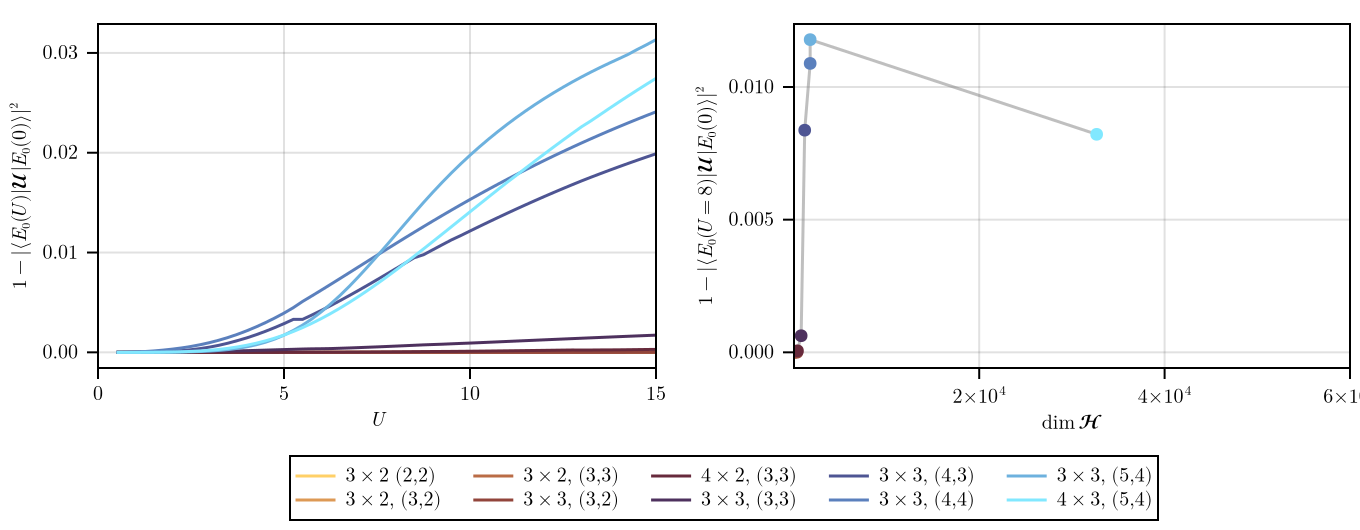

CairoMakie.Screen{IMAGE}


In [ ]:

println("=== Starting test_infidelity_and_dimH_plots ===")
config = parse_cli_args(ARGS)
selected_U = config[:selected_u]
println("Selected U: $selected_U")

output_dir = joinpath(@__DIR__, "..", "good_images", "final")
fig = generate_infidelity_and_dimH_figure(selected_U; output_dir=output_dir)

@assert fig isa Figure "Output must be a Makie Figure"
println("=== TEST PASSED SUCCESSFULLY: test_infidelity_and_dimH_plots ===")
display(fig)


In [ ]:
using CSV, DataFrames
using CairoMakie

ANSATZ_ORDER = Dict("trotter"=> 0, "exact"=> 1)
LOSS_ORDER = Dict("overlap"=> 0, "energy"=> 1)

indir = "/home/jek354/research/ML-signproblem/experimenting/ed/repeat_optimization_3x2_3_2_u32_noreg"
files = [joinpath(indir, x) for x in sort(readdir(indir))]

header = nothing
rows = []
df = nothing
for path in files
    if df === nothing
        df = CSV.read(path, DataFrame)
    else
        append!(df, CSV.read(path, DataFrame))
    end
end

df

# t_loss = subset(df, "ansatz" => ByRow(==("trotter")), "loss_type" => ByRow(==("energy"))).final_loss
# e_loss = subset(df, "ansatz" => ByRow(==("exact")), "loss_type" => ByRow(==("energy"))).final_loss
# # Shared bin edges covering the full span of both datasets
# b_min = min(minimum(t_loss), minimum(e_loss))
# b_max = max(maximum(t_loss), maximum(e_loss))
# common_bins = range(b_min, b_max, length=50)
# fig, ax = create_fig(1; xlabel="Energy", ylabel="Count")
# hist!(ax, t_loss, bins=common_bins, color=(:orange, 0.4), strokewidth=1, strokecolor=:orange, label="Trotter")
# hist!(ax, e_loss, bins=common_bins, color=(:blue, 0.4), strokewidth=1, strokecolor=:blue, label="Exact")
# axislegend(ax)
# display(fig)



Row,ansatz,loss_type,run,seed,final_loss,infidelity,energy,n_params,initial_loss,elapsed_s,regularization
,String7,String7,Int64,Int64,Float64,Float64,Float64,Int64,Float64,Float64,Int64
1,exact,energy,11,20260926,-6.56579,6.66134e-16,-6.56579,180,-6.56552,92.8686,0
2,exact,energy,12,20260927,-6.56579,4.44089e-16,-6.56579,180,-6.56546,67.8474,0
3,exact,energy,13,20260928,-6.56579,1.11022e-15,-6.56579,180,-6.56551,64.4735,0
4,exact,energy,14,20260929,-6.56579,1.11022e-15,-6.56579,180,-6.5655,67.3709,0
5,exact,energy,15,20260930,-6.56579,2.22045e-16,-6.56579,180,-6.56551,69.2223,0
6,exact,energy,16,20260931,-6.56579,0.0,-6.56579,180,-6.5654,68.1858,0
7,exact,energy,17,20260932,-6.56579,5.77316e-15,-6.56579,180,-6.56544,63.0951,0
8,exact,energy,18,20260933,-6.56579,1.77636e-14,-6.56579,180,-6.56549,59.1245,0
9,exact,energy,19,20260934,-6.56579,2.22045e-16,-6.56579,180,-6.56539,73.5763,0


In [ ]:
subset(df, "ansatz" => ByRow(==("trotter")), "loss_type" => ByRow(==("energy"))).final_loss

100-element Vector{Float64}:
 -6.565793293877446
 -6.565793293877447
 -6.565793293877448
 -6.565793293877451
 -6.5657932938774355
 -6.565793293877448
 -6.56579329387745
 -6.565793293877449
 -6.565793293877449
 -6.5657932938774515
 -6.5657932938774435
 -6.565793293877447
 -6.565793293877448
  ⋮
 -6.5657932938774515
 -6.565793293877452
 -6.565793293877412
 -6.565793293877452
 -6.565793293877421
 -6.5657932938774515
 -6.565793293877444
 -6.565793293877448
 -6.565793293877452
 -6.565793293877416
 -6.565793293877452
 -6.565793293877446

## Figure (a): Energy Error vs Sector Dimension ($\dim \mathcal{H}$)
Plots $|E_{\textrm{approx}} - E_{\textrm{true}}|$ vs sector dimension $\dim \mathcal{H}$ on a log-log scale for exact-exponential UCC against the post-hoc "Trotterized exact exp" sweep (already-optimized exact-exp coefficients, repeated $P$ times and rescaled by $1/P$, NO re-optimization -- an approximation OF an approximation, so its error can only sit at or above the exact-exp error) at $P \in \{1, 2, 3, 4, 6, 8\}$.


In [ ]:
output_dir

"/home/jek354/research/ML-signproblem/experimenting/ed/dimH_barren_plots"

Building plot (a): energy error vs dimH...
Saved figure (a) to: /home/jek354/research/ML-signproblem/experimenting/ed/good_images/final/energy_error_vs_dimH.png


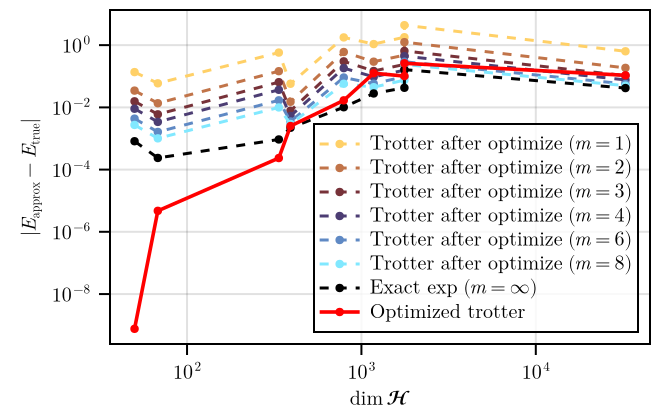

In [11]:
println("Building plot (a): energy error vs dimH...")
fig_a = build_energy_error_vs_dimH_plot(sweep_data, trotter_orders_a)
save(joinpath(output_dir, "energy_error_vs_dimH.png"), fig_a)
save(joinpath(output_dir, "energy_error_vs_dimH.pdf"), fig_a)
println("Saved figure (a) to: ", joinpath(output_dir, "energy_error_vs_dimH.png"))
fig_a


## Figure (a-alt): Overlap vs Sector Dimension ($\dim \mathcal{H}$)
Plots overlap (or infidelity $1 - |\langle E_0(U)|\mathcal{U}|\psi_\text{ref}\rangle|^2$ with `use_infidelity=true`) vs sector dimension $\dim \mathcal{H}$ comparing exact-exponential UCC against the same post-hoc "Trotterized exact exp" sweep at $P \in \{1, 2, 3, 4, 6, 8\}$.


Building plot (a-alt): overlap vs dimH...
Saved figure (a-alt) to: /home/jek354/research/ML-signproblem/experimenting/ed/good_images/final/overlap_vs_dimH.png


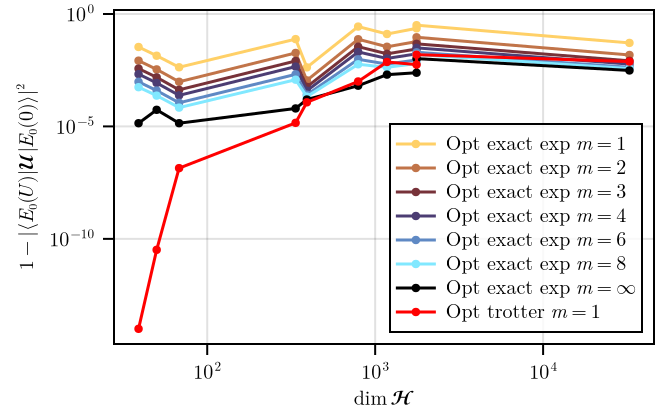

In [12]:
println("Building plot (a-alt): overlap vs dimH...")
fig_a_overlap = build_overlap_vs_dimH_plot(sweep_data, trotter_orders_a; use_infidelity=true, legend_pos=:rb)
save(joinpath(output_dir, "overlap_vs_dimH.png"), fig_a_overlap)
save(joinpath(output_dir, "overlap_vs_dimH.pdf"), fig_a_overlap)
println("Saved figure (a-alt) to: ", joinpath(output_dir, "overlap_vs_dimH.png"))
fig_a_overlap


## Figure (b): Overlap and Energy vs Trotter Order for $N=(5, 4)_{4\times 3}$
Plots overlap (left) and energy (right) as a function of Trotter order $P = 1 \dots 10$ using post-hoc scaled exact-exp coefficients, compared against exact exponential and re-optimized Trotter ($P=1$) reference lines.


In [ ]:
println("Building plot (b): overlap+energy vs Trotter order...")
fig_b = build_overlap_energy_vs_trotter_order_plot(
    exact_energy, exact_overlap, opt_trotter_energy, opt_trotter_overlap,
    orders_b, energies_after, overlaps_after,
)
save(joinpath(output_dir, "overlap_energy_vs_trotter_order.png"), fig_b)
save(joinpath(output_dir, "overlap_energy_vs_trotter_order.pdf"), fig_b)
println("Saved figure (b) to: ", joinpath(output_dir, "overlap_energy_vs_trotter_order.png"))
fig_b


## Figure (c): Barren Plateau Analysis (Gradient Norm vs $\dim \mathcal{H}$)
Initial-gradient-norm statistics normalized per parameter ($\|\nabla \mathcal{L}\| / \sqrt{n_{\textrm{params}}}$) comparing UCC ($P=1$) with deeper VQE-like ansatz ($P=4$), loaded from the barren_study runs optimized with ENERGY (Hamiltonian) loss (`LOSS_TYPE_BARREN`), not the overlap-loss runs used by figures (a)/(a-alt)/(b):
- Left panel: Mean gradient magnitude vs $\dim \mathcal{H}$
- Right panel: Standard deviation of gradient magnitude vs $\dim \mathcal{H}$


In [ ]:
println("Building plot (c): barren-plateau gradient statistics vs dimH...")
fig_c = build_barren_plateau_vs_dimH_plot(sweep_data, P_vqe)
save(joinpath(output_dir, "barren_plateau_vs_dimH.png"), fig_c)
save(joinpath(output_dir, "barren_plateau_vs_dimH.pdf"), fig_c)
println("Saved figure (c) to: ", joinpath(output_dir, "barren_plateau_vs_dimH.png"))
fig_c


# Time benchmarking

In [ ]:
using CSV, DataFrames
path = "/home/jek354/research/ML-signproblem/experimenting/ed/benchmarks"
df = nothing
for ansatz in ["trotter", "exact"]
    for acceleration in ["gpu", "cpu80"]
        f = joinpath(path, "timings_$(ansatz)_$(acceleration).csv")
        isfile(f) || continue
        new_df = CSV.read(f, DataFrame; stringtype=String)
        if df === nothing
            df = new_df
        else
            append!(df, new_df; promote=true)
        end
    end
end
display(df)

Row,code,system,lattice,n_up,n_dn,dim,loss,num_exponentials,device,threads,gpu,n_params,u_index,U,loss_value,forward_min_s,forward_median_s,forward_mean_s,forward_std_s,gradient_min_s,gradient_median_s,gradient_mean_s,gradient_std_s,backward_median_s,gradient_over_forward,compile_forward_s,compile_gradient_s,setup_s,reps,warmup,magnitude,datatype,antihermitian,ref_state,julia_version,hostname,timestamp,tag
,String,String,String,Int64,Int64,Int64,String,Int64,String,Int64,String?,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,String,Bool,String,String,String,DateTime,String
1,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,overlap,1,gpu,1,NVIDIA A100 80GB PCIe,432,33,8.0,0.81929,0.0119653,0.0120926,0.0120753,7.52885e-5,0.0630711,0.0635976,0.0635898,0.000322319,0.051505,5.25922,7.5006,4.75707,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:11:54,gpu
2,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,overlap,2,gpu,1,NVIDIA A100 80GB PCIe,864,33,8.0,0.81634,0.0237822,0.0299984,0.0285781,0.0028768,0.12432,0.127382,0.127258,0.00251214,0.097384,4.24631,0.0256491,0.128794,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:11:56,gpu
3,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,overlap,4,gpu,1,NVIDIA A100 80GB PCIe,1728,33,8.0,0.81541,0.0464456,0.0495399,0.0491991,0.00242567,0.255778,0.265566,0.264076,0.00474294,0.216026,5.36065,0.0483092,0.250277,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:11:59,gpu
4,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,overlap,8,gpu,1,NVIDIA A100 80GB PCIe,3456,33,8.0,0.809055,0.0950015,0.0960033,0.0963984,0.00113755,0.512036,0.531273,0.526469,0.00855437,0.43527,5.53391,0.0983193,0.498724,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:12:04,gpu
5,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,energy,1,gpu,1,NVIDIA A100 80GB PCIe,432,33,8.0,-2.22432,0.0120936,0.012168,0.0121829,8.06073e-5,0.0624363,0.0628502,0.0628861,0.000328919,0.0506822,5.1652,0.146651,0.413589,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:12:07,gpu
6,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,energy,2,gpu,1,NVIDIA A100 80GB PCIe,864,33,8.0,-2.21032,0.0235131,0.0236379,0.0237041,0.000211899,0.124816,0.124924,0.125082,0.000373162,0.101287,5.28493,0.0253543,0.124663,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:12:08,gpu
7,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,energy,4,gpu,1,NVIDIA A100 80GB PCIe,1728,33,8.0,-2.16501,0.0509728,0.0520217,0.0524033,0.0011483,0.250434,0.257604,0.255696,0.00359473,0.205583,4.95187,0.0516775,0.246913,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:12:11,gpu
8,trotter,"N=(4, 3)_3x3",3x3,4,3,1176,energy,8,gpu,1,NVIDIA A100 80GB PCIe,3456,33,8.0,-2.28022,0.0970039,0.0979993,0.097999,0.00070499,0.502447,0.51487,0.512669,0.00586836,0.416871,5.25382,0.0998683,0.492988,13.4605,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:12:16,gpu
9,trotter,"N=(5, 4)_3x3",3x3,5,4,1764,overlap,1,gpu,1,NVIDIA A100 80GB PCIe,432,33,8.0,0.767849,0.0149991,0.017993,0.0171975,0.00164264,0.0631442,0.0643266,0.0640292,0.000644216,0.0463336,3.57508,0.0402784,0.0635538,0.126122,5,1,0.01,ComplexF64,true,slater,1.12.5,kim-compute-03.physics.cornell.edu,2026-09-16T12:12:18,gpu


In [ ]:
df_tmp = select(df,[:code, :loss, :n_params, :device, :dim, :gradient_mean_s, :forward_mean_s])
filter(row -> row.loss == "overlap" && row.code == "exact" && row.device=="gpu", df_tmp)

Row,code,loss,n_params,device,dim,gradient_mean_s,forward_mean_s
,String,String,Int64,String,Int64,Float64,Float64
1,exact,overlap,585,gpu,1176,9.93102,0.110999
2,exact,overlap,585,gpu,1764,9.92619,0.0680154
3,exact,overlap,1368,gpu,32670,34.2083,0.870801


In [ ]:
filter(row -> row.loss == "overlap" && row.code == "trotter" && row.device=="gpu", df_tmp)

Row,code,loss,n_params,device,dim,gradient_mean_s,forward_mean_s
,String,String,Int64,String,Int64,Float64,Float64
1,trotter,overlap,432,gpu,1176,0.0635898,0.0120753
2,trotter,overlap,864,gpu,1176,0.127258,0.0285781
3,trotter,overlap,1728,gpu,1176,0.264076,0.0491991
4,trotter,overlap,3456,gpu,1176,0.526469,0.0963984
5,trotter,overlap,432,gpu,1764,0.0640292,0.0171975
6,trotter,overlap,864,gpu,1764,0.128136,0.0273975
7,trotter,overlap,1728,gpu,1764,0.262129,0.0536004
8,trotter,overlap,3456,gpu,1764,0.525926,0.105999
9,trotter,overlap,1092,gpu,32670,0.30868,0.0845989
